# Загрузка Датасета

In [1]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([transforms.ToTensor()])

In [2]:
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

## Создание загрузчиков

In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

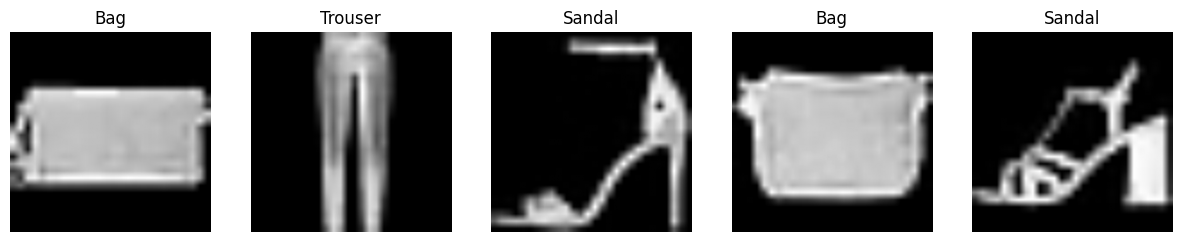

In [4]:
import matplotlib.pyplot as plt

# Официальные названия классов Fashion MNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Вытягиваем один батч данных
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Отрисовка первых 5 примеров из батча
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # PyTorch отдает тензор формата [Каналы, Высота, Ширина].
    # У нас ч/б картинки (1 канал), так что делаем squeeze(), чтобы убрать лишнее измерение для отрисовки.
    img = images[i].squeeze()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(classes[labels[i].item()])
    axes[i].axis('off')

plt.show()

# Загрузка модели

In [6]:
import timm

In [7]:
MODEL_NAME = 'vit_tiny_patch16_224'

In [ ]:
model = timm.create_model(
        'vit_tiny_patch16_224', 
        pretrained=False, 
        num_classes=10, 
        in_chans=3,
        img_size=32, 
        patch_size=4
    )

# Обучение

In [9]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_2888/3321804261.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [12]:
for epoch in range(epochs):
    print(f"\nЭпоха {epoch+1}/{epochs}")
    print(f"Текущий Learning Rate: {scheduler.get_last_lr()[0]:.6f}")

    # --- ТРЕНИРОВКА ---
    model.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in tqdm(train_loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Контекст-менеджер смешанной точности
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Обертка обратного прохода и шага оптимизатора через scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    # --- ВАЛИДАЦИЯ ---
    model.eval()
    val_loss, val_correct = 0.0, 0

    # Градиенты на валидации не нужны, отключаем для экономии памяти
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Eval", leave=False):
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    # Шаг шедулера делаем в конце эпохи
    scheduler.step()

    # Вывод метрик
    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(test_loader.dataset)

    print(f"Train Loss: {train_loss / len(train_loader.dataset):.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss / len(test_loader.dataset):.4f} | Val Acc: {val_acc:.4f}")


Эпоха 1/10
Текущий Learning Rate: 0.001000


Train:   0%|          | 0/938 [00:00<?, ?it/s]

/tmp/ipykernel_2888/259934497.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Eval:   0%|          | 0/157 [00:00<?, ?it/s]

/tmp/ipykernel_2888/259934497.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Eval:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: nan | Train Acc: 0.8835
Val Loss: 0.3572 | Val Acc: 0.8712

Эпоха 10/10
Текущий Learning Rate: 0.000024


Train:   0%|          | 0/938 [00:00<?, ?it/s]

Eval:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.2896 | Train Acc: 0.8925
Val Loss: 0.3431 | Val Acc: 0.8739


In [13]:
torch.save(model.cpu().state_dict(), 'vit_t_fashion.pth')